In [ ]:
import re

# --- NUEVO MOTOR MATEMÁTICO CORREGIDO ---
def expand_vibrational_reactions(line_str):
    """
    Toma una línea con rangos como 'v=1:41' o 'w=v:40' y álgebra como 'v-1'
    y la expande en todas sus reacciones individuales sin romper los nombres.
    """
    # 1. Buscamos si hay rangos definidos para 'v' o 'w'
    v_match = re.search(r'v=(\d+):(\d+)', line_str)
    w_match = re.search(r'w=(v|\d+):(\d+)', line_str)
    
    # Si no hay rangos (ej. O2(X,v=0) normal o e + O(3P)), devolvemos la línea tal cual
    if not v_match and not w_match:
        return [line_str]
        
    v_start = int(v_match.group(1)) if v_match else None
    v_end = int(v_match.group(2)) if v_match else None
    
    w_start_raw = w_match.group(1) if w_match else None
    w_end = int(w_match.group(2)) if w_match else None
    
    expanded_lines = []
    
    # 2. Iteramos sobre los valores del rango principal 'v'
    v_values = range(v_start, v_end + 1) if v_match else [None]
    
    for v in v_values:
        # Determinamos el inicio de 'w' (puede ser un número fijo o depender de 'v')
        if w_match:
            w_start = v if w_start_raw == 'v' else int(w_start_raw)
            w_values = range(w_start, w_end + 1)
        else:
            w_values = [None]
            
        for w in w_values:
            
            # 3. Función interna que solo ataca lo que hay dentro de O2(X, ...)
            def replacer(match):
                expr = match.group(1) # Extrae ej. 'v=1:41', 'w=v-1', 'v=41'
                
                # Separamos la variable de su valor/operación
                if '=' in expr:
                    left, right = expr.split('=', 1)
                else:
                    left, right = 'v', expr
                    
                # Caso A: Es la definición del rango (tiene ':'). Cogemos el valor del bucle.
                if ':' in right:
                    val = v if left == 'v' else w
                # Caso B: Es una operación matemática (v-1) o un número estático (41)
                else:
                    env = {}
                    if v is not None: env['v'] = v
                    if w is not None: env['w'] = w
                    try:
                        # Resuelve matemáticamente la expresión usando los valores de v y w
                        val = eval(right, {"__builtins__": None}, env) 
                    except Exception:
                        val = right
                        
                # Forzamos el formato estandarizado para que la red agrupe bien los nodos
                return f"O2(X,v={val})"
                
            # 4. Aplicamos el reemplazo quirúrgico a la línea actual
            new_line = re.sub(r'O2\(X,([^)]+)\)', replacer, line_str)
            expanded_lines.append(new_line)
            
    return expanded_lines
def solve_algebra(text, var_dict):
    """
    Busca patrones de álgebra (ej. v-1, w+2) y los resuelve con los valores actuales.
    """
    for var, val in var_dict.items():
        # Reemplazamos la variable aislada (ej. O2(X,v=v) -> O2(X,v=5))
        text = re.sub(rf'\b{var}\b(?!\+|\-)', str(val), text)
        
        # Buscamos restas: v-1, w-2, etc.
        for match in re.finditer(rf'{var}-(\d+)', text):
            sub_val = int(match.group(1))
            result = val - sub_val
            text = text.replace(match.group(0), str(result))
            
        # Buscamos sumas: v+1, w+2, etc.
        for match in re.finditer(rf'{var}\+(\d+)', text):
            add_val = int(match.group(1))
            result = val + add_val
            text = text.replace(match.group(0), str(result))
            
    return text


# --- FUNCIONES ADAPTADAS ---
def parseChemFile(file):
    """Parsea el archivo químico, expande vibraciones y extrae especies y reacciones."""
    with open(file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    uniqueSpecies = []
    reactions = []
    
    for line in lines:
        cleanLine = line.strip()
        # Ignorar líneas vacías o comentarios puros
        if not cleanLine or cleanLine.startswith('%'):
            continue
            
        # Separar la reacción de los datos cinéticos usando el delimitador '|'
        reaction_str_raw = cleanLine.split('|')[0].strip()
        
        if not reaction_str_raw:
            continue
            
        # ¡AQUÍ ESTÁ LA MAGIA! Expandimos la línea si tiene vibraciones
        expanded_reaction_strings = expand_vibrational_reactions(reaction_str_raw)
        
        for react_str in expanded_reaction_strings:
            try:
                reaction = parseReactionStr(react_str)
            except ValueError:
                # Si hay alguna línea rara que no sea una reacción, la saltamos
                continue
            
            if reaction not in reactions:
                reactions.append(reaction)
                
            # Extraer especies únicas
            for species in reaction['lhsSpecies'] + reaction['rhsSpecies']:
                if species not in uniqueSpecies:
                    uniqueSpecies.append(species)

    return uniqueSpecies, reactions

def parseReactionStr(reactionStr):
    """Parsea el string de la reacción para dividir lados y estequiometría."""
    if '<->' in reactionStr:
        backwardReaction = True
        lhsStr, rhsStr = reactionStr.split('<->')
    elif '->' in reactionStr:
        backwardReaction = False
        lhsStr, rhsStr = reactionStr.split('->')
    else:
        raise ValueError(f"Formato de reacción no válido: {reactionStr}")
    
    lhsSpecies, lhsStoichiometricCoeffs = parseSpeciesStr(lhsStr)
    rhsSpecies, rhsStoichiometricCoeffs = parseSpeciesStr(rhsStr)
    
    reaction = {
        'description': reactionStr,
        'lhsSpecies': lhsSpecies,
        'lhsStoichiometricCoeffs': lhsStoichiometricCoeffs,
        'rhsSpecies': rhsSpecies,
        'rhsStoichiometricCoeffs': rhsStoichiometricCoeffs,
        'backwardReaction': backwardReaction
    }
    return reaction

def parseSpeciesStr(species_string):
    """Parsea el lado de una reacción extrayendo coeficientes y nombres de especies."""
    species_list = []
    coeff_list = []
    
    parts = species_string.strip().split(' + ')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
        
        # Regex para capturar el coeficiente y la especie
        match = re.match(r'^(\d*\.?\d*)(.+)$', part)
        if match:
            coeff_str = match.group(1)
            species = match.group(2).strip()
            
            if coeff_str:
                coeff = float(coeff_str) if '.' in coeff_str else int(coeff_str)
            else:
                coeff = 1
            
            if species not in species_list:
                species_list.append(species)
                coeff_list.append(coeff)
            else:
                index = species_list.index(species)
                coeff_list[index] += coeff

    return species_list, coeff_list

# --- FUNCIÓN MAIN ---
def main(file):
    print(f"Leyendo el archivo: {file}...\n")
    uniqueSpecies, reactions = parseChemFile(file)

    print(f'--- Especies Únicas Encontradas: {len(uniqueSpecies)} ---')
    print(f'--- Número total de Reacciones: {len(reactions)} ---')
    
    print('\n--- Detalle de una Reacción Expandida (Ejemplo) ---')
    if len(reactions) > 100:
        # Cogemos una del medio para ver cómo resolvió el álgebra vibracional
        reaction = reactions[-10] 
        print(f"Descripción procesada: {reaction['description']}")
        print(f"Es reversible: {'Sí' if reaction['backwardReaction'] else 'No'}")
        
        for idx in range(len(reaction['lhsSpecies'])):
            print(f"Reactivo (Izq): {reaction['lhsStoichiometricCoeffs'][idx]} {reaction['lhsSpecies'][idx]}")
        for idx in range(len(reaction['rhsSpecies'])):
            print(f"Producto (Der): {reaction['rhsStoichiometricCoeffs'][idx]} {reaction['rhsSpecies'][idx]}")

    return 0

if __name__ == "__main__":
    main('oxygen_vib.chem')

Leyendo el archivo: oxygen_vib.chem...

--- Especies Únicas Encontradas: 55 ---
--- Número total de Reacciones: 3606 ---

--- Detalle de una Reacción Expandida (Ejemplo) ---
Descripción procesada: O2(X,v=32) + wall -> O2(X,v=31)
Es reversible: No
Reactivo (Izq): 1 O2(X,v=32)
Reactivo (Izq): 1 wall
Producto (Der): 1 O2(X,v=31)


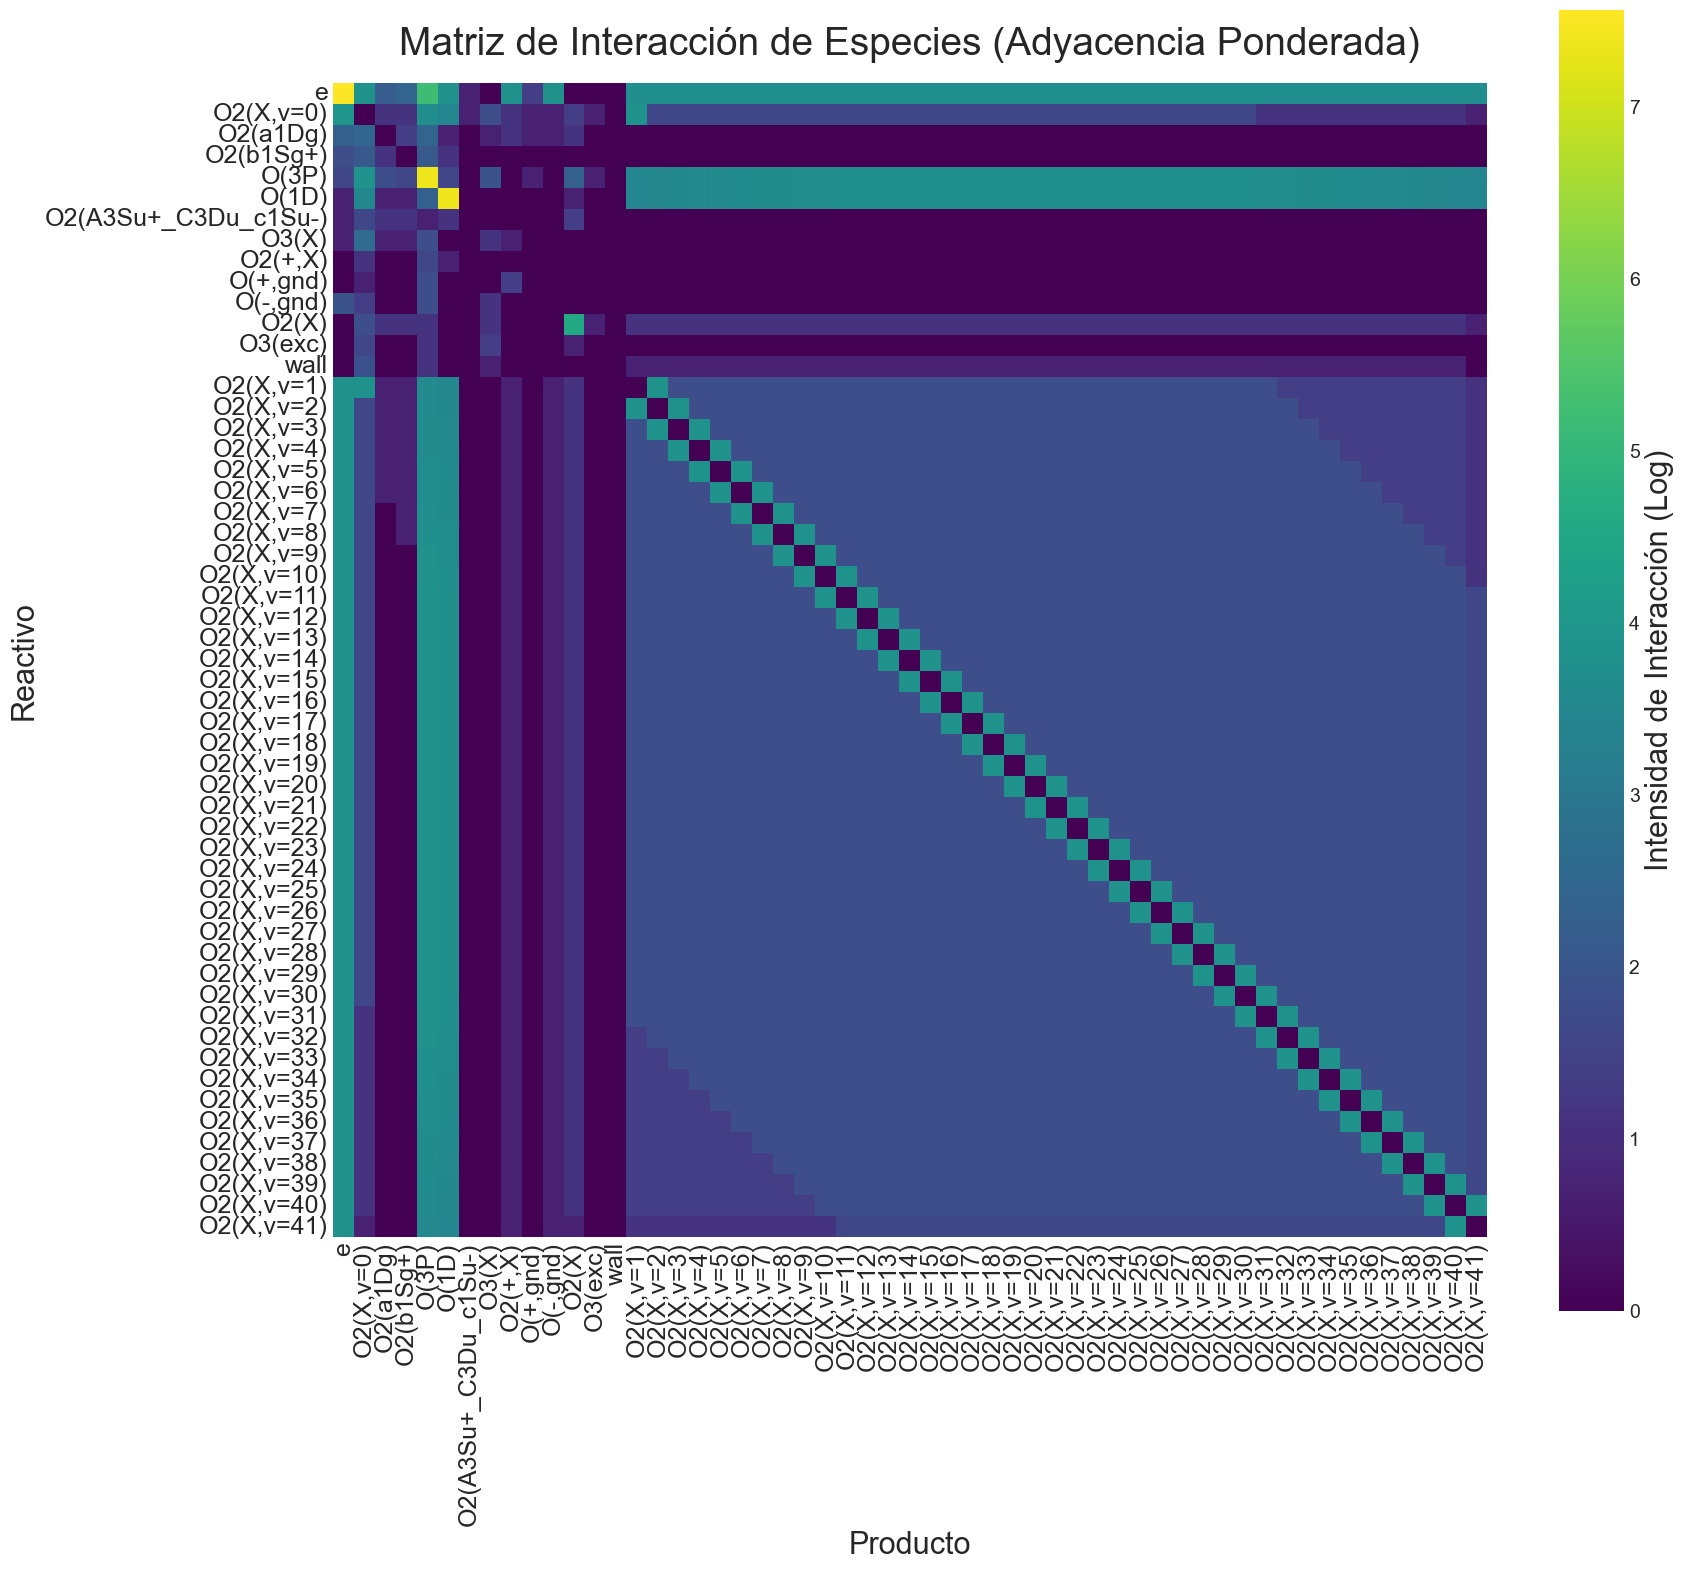

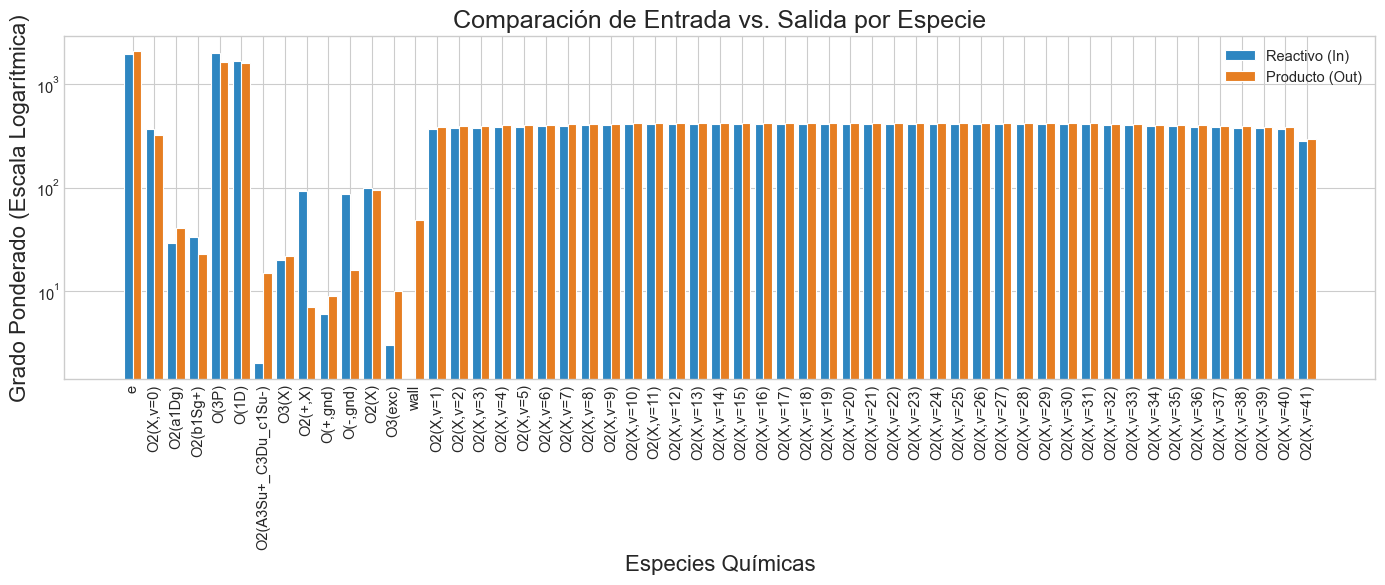

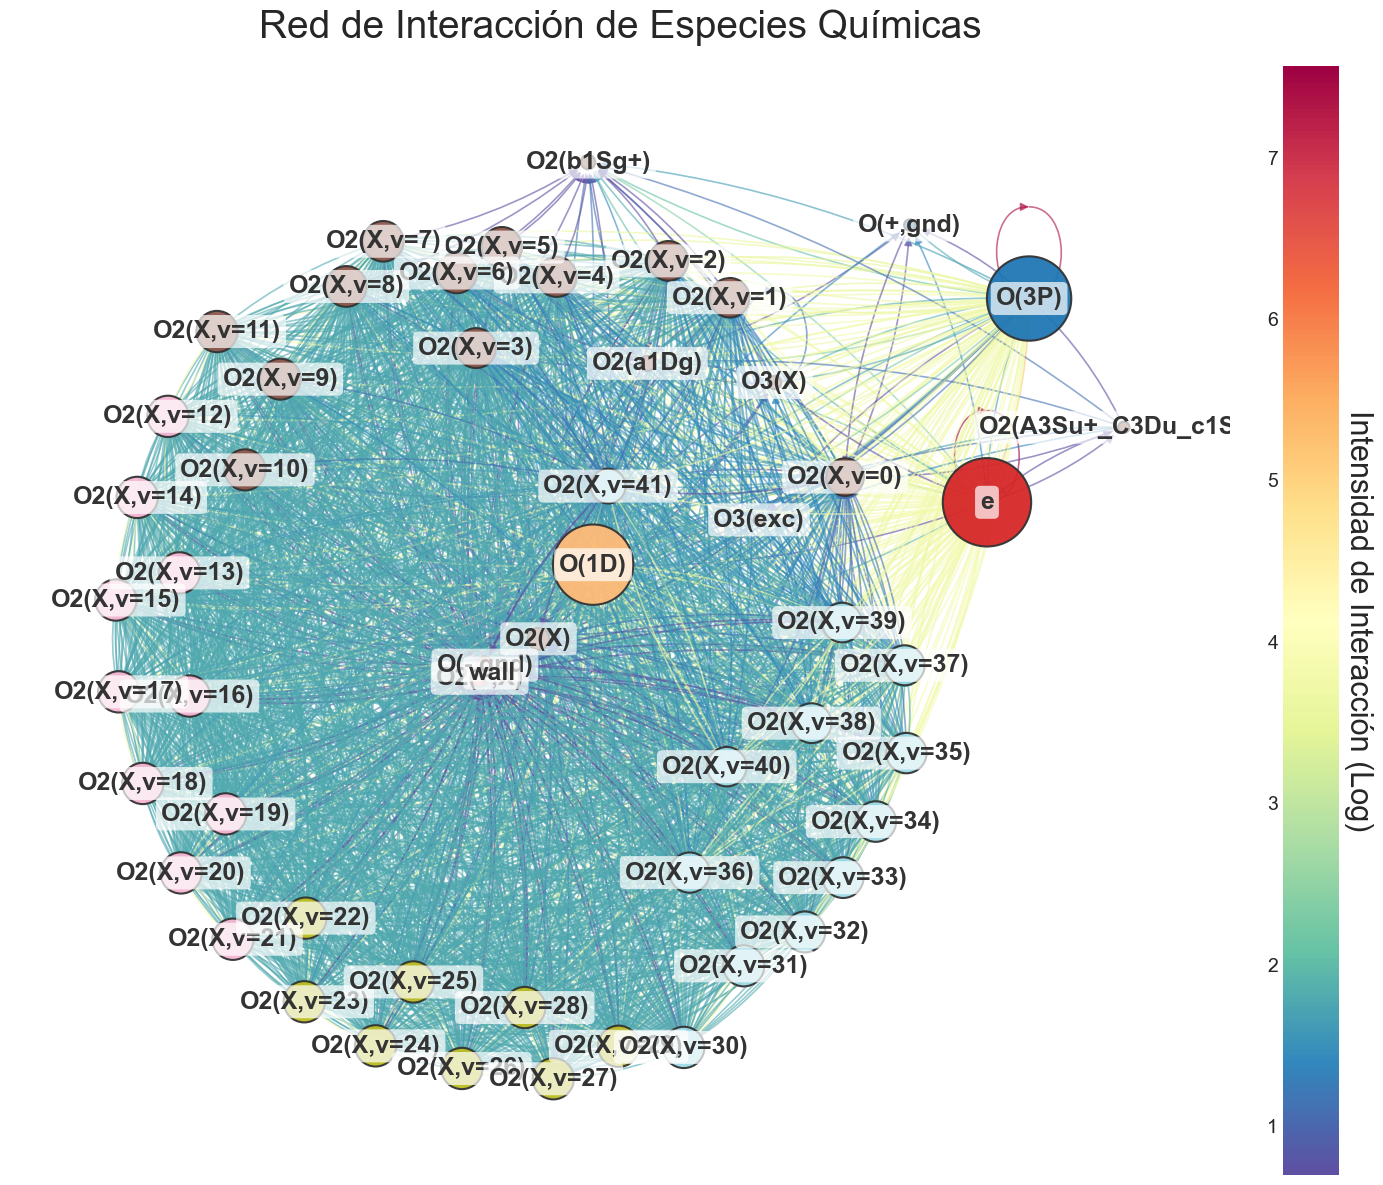

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from networkx.algorithms import community

uniqueSpecies, reactions = parseChemFile('oxygen_vib.chem')
G = nx.DiGraph()
G.add_nodes_from(uniqueSpecies)

for r in reactions:
    # Sentido directo
    for src in r['lhsSpecies']:
        for dst in r['rhsSpecies']:
            w = r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(src)] * \
                r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(dst)]
            if G.has_edge(src, dst): G[src][dst]['weight'] += w
            else: G.add_edge(src, dst, weight=w)
    # Sentido inverso
    if r['backwardReaction']:
        for src in r['rhsSpecies']:
            for dst in r['lhsSpecies']:
                w = r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(src)] * \
                    r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(dst)]
                if G.has_edge(src, dst): G[src][dst]['weight'] += w
                else: G.add_edge(src, dst, weight=w)

# --- 3. VISUALIZACIONES ---

# A. Matriz de Adyacencia (Heatmap)
orden_nodos = list(G.nodes)
vector_nodos = np.array(orden_nodos)
np.save('orden_nodos_oxigeno_vib.npy', vector_nodos)
matriz_adyacencia = nx.to_numpy_array(G, nodelist=orden_nodos)

df_adj = pd.DataFrame(np.log1p(matriz_adyacencia), 
                      index=orden_nodos, 
                      columns=orden_nodos)

plt.figure(figsize=(18, 16))
ax_heatmap = sns.heatmap(df_adj, 
                         cmap='viridis',
                         xticklabels=True,
                         yticklabels=True,
                         square=True)


cbar = ax_heatmap.collections[0].colorbar
cbar.set_label('Intensidad de Interacción (Log)', fontsize=22)
cbar.ax.tick_params(labelsize=14)

plt.title('Matriz de Interacción de Especies (Adyacencia Ponderada)', fontsize=28, pad=20)
plt.xlabel('Producto', fontsize=22)
plt.ylabel('Reactivo', fontsize=22)

# Etiquetas de especies a tamaño 13
plt.xticks(rotation=90, fontsize=18) 
plt.yticks(rotation=0, fontsize=18)
plt.tight_layout()
plt.show()

# B. Comparación Grados de Entrada/Salida
in_deg = [np.sum(matriz_adyacencia[:, i]) - matriz_adyacencia[i,i] for i in range(len(orden_nodos))]
out_deg = [np.sum(matriz_adyacencia[i, :]) - matriz_adyacencia[i,i] for i in range(len(orden_nodos))]
x = np.arange(len(orden_nodos))

plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, in_deg, 0.4, label='Reactivo (In)', color='#2E86C1', log=True)
plt.bar(x + 0.2, out_deg, 0.4, label='Producto (Out)', color='#E67E22', log=True)

plt.xticks(x, orden_nodos, rotation=90)
plt.legend()

plt.title('Comparación de Entrada vs. Salida por Especie', fontsize=18)
plt.ylabel('Grado Ponderado (Escala Logarítmica)', fontsize=16)
plt.xlabel('Especies Químicas', fontsize=16)

plt.tight_layout()
plt.savefig('grados_O2.png')

# C. Proyección de la Red
pos = nx.kamada_kawai_layout(G)
grado_total = [in_deg[i] + out_deg[i] for i in range(len(orden_nodos))]
node_sizes = [50 + g for g in grado_total]
np.save('grado_total_oxigeno_vib.npy', grado_total)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
weights_log = np.log1p(weights)

comunidades = community.louvain_communities(G, weight='weight', seed=123)
mapa_comunidades = {nodo: i for i, comm in enumerate(comunidades) for nodo in comm}
node_color_values = [mapa_comunidades[nodo] for nodo in G.nodes()]

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 12), dpi=100)

nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=weights_log,
                       edge_cmap=plt.cm.Spectral_r, width=1.2, alpha=0.6,
                       arrowsize=12, arrowstyle='-|>', connectionstyle="arc3,rad=0.1")

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_color_values,
                       cmap=plt.cm.tab20, edgecolors='#333333', linewidths=1.5, alpha=0.95)

pos_labels = {k: (v[0], v[1]) for k, v in pos.items()} 
labels = nx.draw_networkx_labels(G, pos_labels, ax=ax, font_size=18, font_family='sans-serif',
                                 font_weight='bold', font_color='#333333')

for t in labels.values():
    t.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

# 6. BARRA DE COLOR Y DETALLES FINALES
sm = plt.cm.ScalarMappable(cmap=plt.cm.Spectral_r, norm=plt.Normalize(vmin=min(weights_log), vmax=max(weights_log)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_ticks_position('left')

# Modificas el tamaño de los números de la escala
cbar.ax.tick_params(labelsize=14)

# La etiqueta se queda a la derecha, pero le damos un poco de labelpad por si acaso
cbar.set_label('Intensidad de Interacción (Log)', rotation=270, labelpad=25, fontsize=22)
cbar.outline.set_visible(False)

ax.set_title("Red de Interacción de Especies Químicas", fontsize=28, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

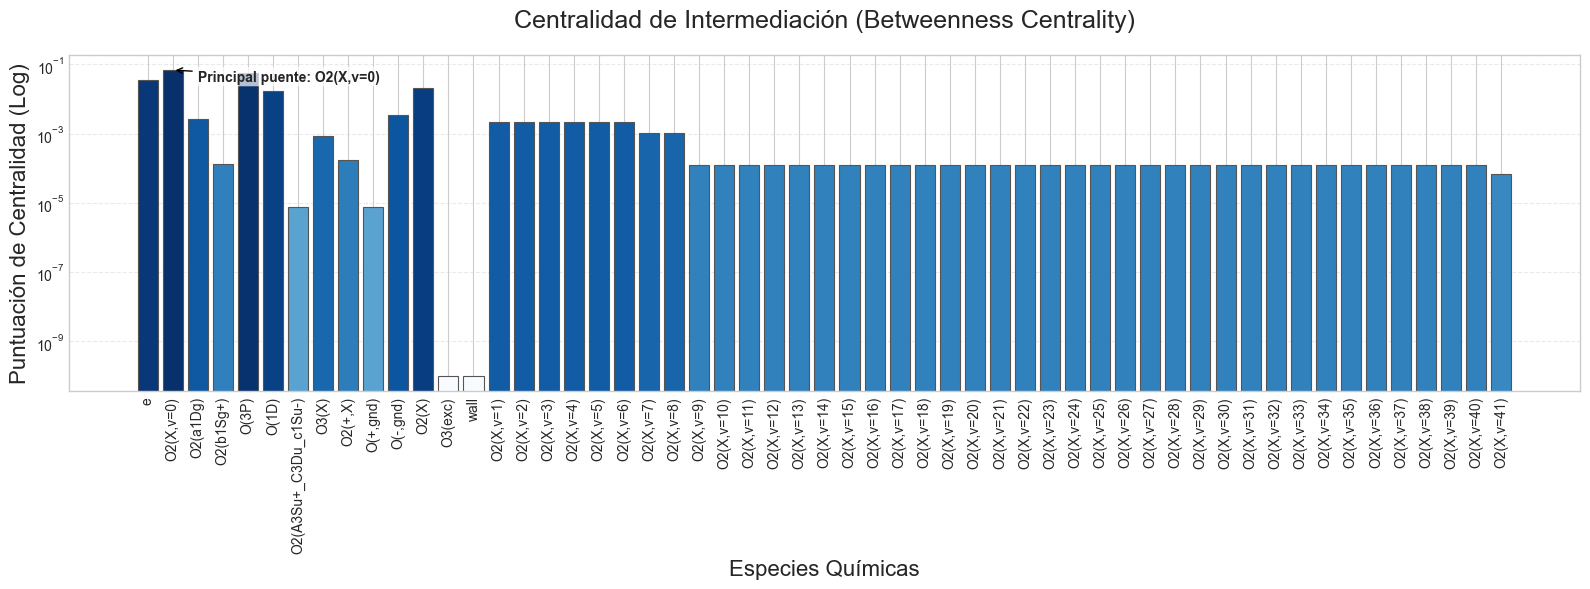

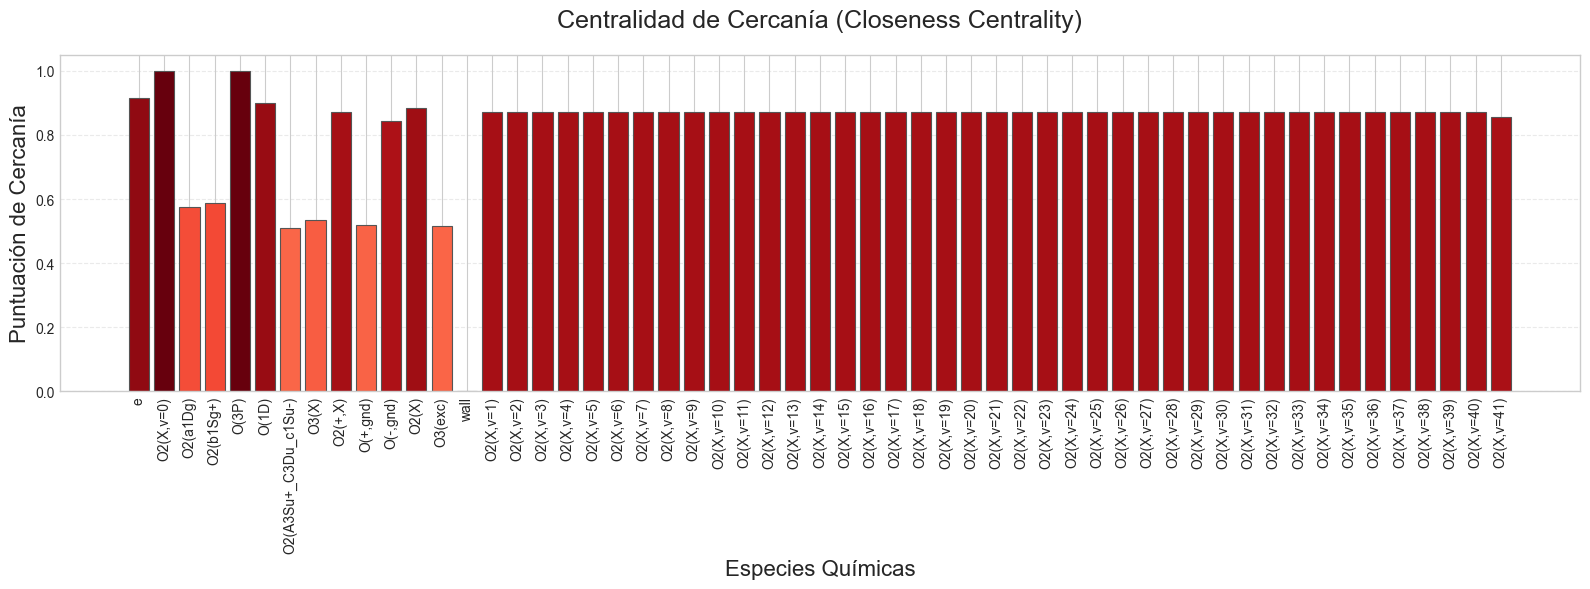

In [ ]:
import networkx as nx 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors  
from networkx.algorithms import community


# =============================================================================
# 1. CENTRALIDAD DE INTERMEDIACIÓN (BETWEENNESS) - ORDEN ORIGINAL Y CORREGIDO
# =============================================================================
centrality = nx.betweenness_centrality(G)
np.save('centralidad_b_oxigeno.npy', list(centrality.values()))

# Extraemos los nodos y valores manteniendo el ORDEN ORIGINAL del grafo
nodes_b = list(G.nodes())
values_b = list(centrality.values())

plt.figure(figsize=(16, 6))

# Evitamos ceros puros para que el logaritmo y el degradado no den error
values_b_plot = [v if v > 0 else 1e-10 for v in values_b]

# Normalización logarítmica para los colores (respeta los saltos gigantes de magnitud)
norm_b = mcolors.LogNorm(vmin=min(values_b_plot), vmax=max(values_b_plot))
colors_b = plt.cm.Blues(norm_b(values_b_plot))

# Dibujamos las barras con borde gris oscuro (#555555) para que NINGUNA desaparezca
plt.bar(nodes_b, values_b_plot, color=colors_b, edgecolor='#555555', linewidth=0.8)
plt.yscale('log') 

plt.title('Centralidad de Intermediación (Betweenness Centrality)', fontsize=18, pad=20)
plt.ylabel('Puntuación de Centralidad (Log)', fontsize=16)
plt.xlabel('Especies Químicas', fontsize=16)

plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Encontrar automáticamente el nodo TOP 1 para ponerle la flecha
max_idx_b = np.argmax(values_b)
max_val_b = values_b_plot[max_idx_b]

# Resaltar el Top 1 donde quiera que esté en el eje X
plt.annotate(f'Principal puente: {nodes_b[max_idx_b]}', 
             xy=(max_idx_b, max_val_b), 
             xytext=(max_idx_b + 1, max_val_b * 0.5), # Texto ligeramente a la derecha
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.savefig('histograma_betweenness_oxigeno.png', dpi=300) # Guarda en alta calidad
plt.show()


# =============================================================================
# 2. CENTRALIDAD DE CERCANÍA (CLOSENESS) - ORDEN ORIGINAL
# =============================================================================
closeness_centrality = nx.closeness_centrality(G)
np.save('centralidad_c_oxigeno.npy', list(closeness_centrality.values()))

# Extraemos los nodos y valores manteniendo el ORDEN ORIGINAL
nodes_c = list(G.nodes())
values_c = list(closeness_centrality.values())

plt.figure(figsize=(16, 6))

# Paleta cálida basada en la altura (más alto = rojo más oscuro)
norm_c = plt.Normalize(vmin=min(values_c), vmax=max(values_c))
colors_c = plt.cm.Reds(norm_c(values_c))

# Dibujamos las barras (también con borde oscuro para mantener la estética)
plt.bar(nodes_c, values_c, color=colors_c, edgecolor='#555555', linewidth=0.8)

# Ajustamos el rango Y para que se vea perfectamente la diferencia de alturas
plt.ylim(min(values_c) * 0.95, max(values_c) * 1.05) 

plt.title('Centralidad de Cercanía (Closeness Centrality)', fontsize=18, pad=20)
plt.ylabel('Puntuación de Cercanía', fontsize=16)
plt.xlabel('Especies Químicas', fontsize=16)

plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histograma_closeness_oxigeno.png', dpi=300)
plt.show()

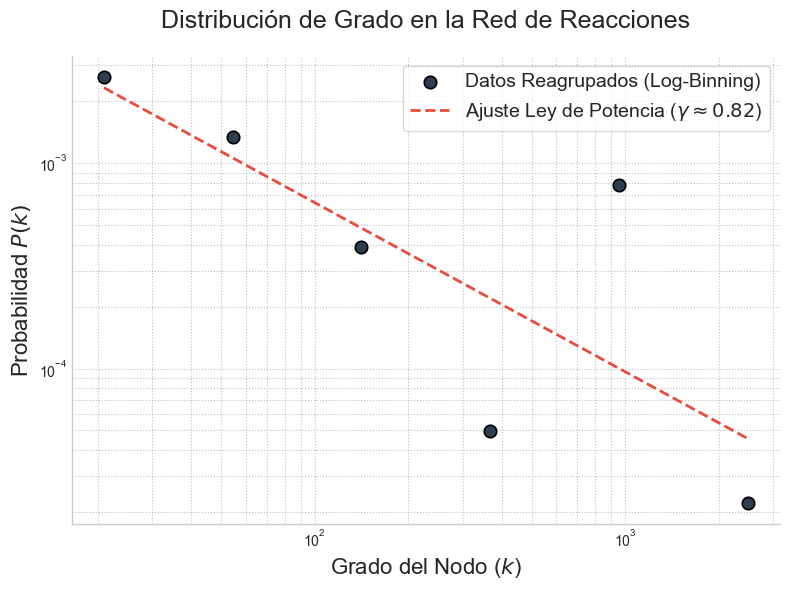

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- FUNCIÓN DE LOG-BINNING ---
def logarithmic_binning(grados, n_bins=50): 
    grados = np.array(grados)
    grados = grados[grados > 0]
    min_exp, max_exp = np.log10(min(grados)), np.log10(max(grados))
    bins = np.logspace(min_exp, max_exp, num=n_bins)
    counts, edges = np.histogram(grados, bins=bins, density=False)
    bin_widths = np.diff(edges)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    density = counts / (bin_widths * len(grados))
    mask = density > 0
    return bin_centers[mask], density[mask]

# 1. Procesamiento de datos
x_binned, y_binned = logarithmic_binning(grado_total, n_bins=7)

# 2. Ajuste Lineal en espacio logarítmico
log_x, log_y = np.log10(x_binned), np.log10(y_binned)
def linear_model(x, m, c): return m * x + c
popt, _ = curve_fit(linear_model, log_x, log_y)
gamma = -popt[0] # El exponente de la ley de potencias

# --- GRÁFICA PROFESIONAL ---
plt.figure(figsize=(8, 6))

plt.scatter(x_binned, y_binned, 
            color='#2c3e50',      
            s=80, 
            edgecolors='black', 
            linewidths=1.2,
            label='Datos Reagrupados (Log-Binning)',
            zorder=3)

# Línea de ajuste
x_line = np.logspace(np.log10(min(x_binned)), np.log10(max(x_binned)), 100)
y_line = (10**popt[1]) * (x_line**popt[0])
plt.plot(x_line, y_line, 
         color='#e74c3c',        
         linestyle='--', 
         linewidth=2, 
         label=rf'Ajuste Ley de Potencia ($\gamma \approx {gamma:.2f}$)',
         zorder=2)

# Configuración de Ejes 
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Grado del Nodo ($k$)', fontsize=16)
plt.ylabel(r'Probabilidad $P(k)$', fontsize=16)
plt.title('Distribución de Grado en la Red de Reacciones', fontsize=18, pad=20)

# Mejorar la rejilla y el marco
plt.grid(True, which="both", ls=":", alpha=0.5, color='gray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Leyenda y Anotación técnica
plt.legend(frameon=True, loc='upper right', fontsize=14)
plt.tight_layout()

plt.show()